# 03 — Event Detection & Sentiment Tagging

**7030DATSCI · Causal Event-Driven Market Impact Modelling**  
**Author:** Ibrahim Haroun · **LJMU 2025–2026** · **Version:** 2.1 (Notebook 01/02 aligned; GDELT integrated as continuous confounder)

---

## Purpose

Transform the standardized event sources produced by `01_data_collection.ipynb` into a unified event catalogue, daily sentiment signals, and a high-impact event subset for `04_causal_analysis.ipynb`.

This revision aligns Notebook 03 with the current Notebook 01/02 data contract:

- APP input: `data/raw/app_presidential_documents_economic.parquet`
- FOMC input: `data/raw/fomc_dates.parquet` with canonical `rate_decision`
- GDELT input: `data/raw/gdelt_daily_summary.parquet`, the full collected 2015–2025 daily stream. Per `10_decision_log.md` (2026-07-13), GDELT is merged into `daily_sentiment.parquet` as a **continuous daily confounder** (the same role VIX plays elsewhere), not minted as a discrete per-day catalogue "event" — averaging tens of thousands of raw GDELT records into one daily mean crushes the signal well below any per-document confidence threshold, so treating each day as a catalogue row would add ~4,000 rows that could never be flagged high-impact and would inflate the geopolitical category far beyond what the event-study design assumes.
- Trading calendar reference: `data/raw/spy_returns.parquet`
- FinBERT is the only accepted APP sentiment engine; no lexicon or fabricated neutral fallback is used
- Event windows, abnormal returns, causal estimation, and predictive feature engineering remain downstream responsibilities

## Inputs

| File | Role |
|---|---|
| `app_presidential_documents_economic.parquet` | Filtered presidential communication corpus |
| `fomc_dates.parquet` | Structured monetary-policy announcements |
| `gdelt_daily_summary.parquet` | Daily GDELT event volume, Goldstein score, and tone (continuous confounder, not a catalogue source) |
| `spy_returns.parquet` | Trading-calendar boundary and validation reference |
| FinBERT cache containing APP sentiment fields | Reproducible sentiment results generated by the project FinBERT pipeline |

## Outputs

| File | Description |
|---|---|
| `data/processed/events_tagged.parquet` | Unified APP + FOMC event catalogue (discrete, dateable events only) |
| `data/processed/daily_sentiment.parquet` | Same-day sentiment aggregates by event type, plus the continuous GDELT risk columns |
| `data/processed/high_impact_events.parquet` | Five-category high-impact subset for downstream analysis |
| `data/processed/gdelt_daily_risk.parquet` | Standardized daily GDELT geopolitical signal (continuous series, all 4,018 days) |

## Scope boundary

Notebook 03 performs classification, sentiment binding, source harmonisation, same-day aggregation, quality checks, and descriptive visualisation. It does **not** construct event windows, estimate CAR/CAAR, run DoWhy, create lagged predictors, train models, or modify the frozen modelling datasets.


---
## 0. Setup and Import Dependencies


In [29]:
# ── 0. Setup and Import Dependencies ──────────────────────────────────────────

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_collector import load_config

config = load_config("../config.yaml")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

for directory in (PROCESSED_DIR, FIG_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by the existing visualisation cells.
PROCESSED = PROCESSED_DIR
FIGURES = FIG_DIR
PALETTE = sns.color_palette("tab10", 10)

START_DATE = pd.Timestamp("2015-01-01")
END_DATE = pd.Timestamp("2025-12-31")
CONFIDENCE_THRESHOLD = 0.70

print(f"✓ Project root: {PROJECT_ROOT}")
print("✓ Environment and output directories initialized.")


✓ Project root: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI
✓ Environment and output directories initialized.


---
## 1. Data Ingestion & Contract Validation

Load only the canonical artifacts produced by Notebook 01. The cell validates required columns before any transformation so schema drift fails early and transparently.


In [30]:
# ── 1. Ingestion of Canonical Notebook 01 Artifacts ───────────────────────────

def load_parquet_required(path: Path, required_columns: set[str]) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required input not found: {path}")
    df = pd.read_parquet(path)
    missing = required_columns.difference(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing)}")
    return df.copy()

app_docs = load_parquet_required(
    RAW_DIR / "app_presidential_documents_economic.parquet",
    {"date", "title", "president", "doc_type", "text", "url"},
)
fomc_df = load_parquet_required(
    RAW_DIR / "fomc_dates.parquet",
    {"date", "rate_decision"},
)
gdelt_daily = load_parquet_required(
    RAW_DIR / "gdelt_daily_summary.parquet",
    {"date", "gdelt_event_count", "gdelt_mean_goldstein", "gdelt_mean_tone"},
)
spy_ret = pd.read_parquet(RAW_DIR / "spy_returns.parquet")

for frame in (app_docs, fomc_df, gdelt_daily):
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce").dt.normalize()

if "date" in spy_ret.columns:
    spy_ret["date"] = pd.to_datetime(spy_ret["date"], errors="coerce").dt.normalize()
    trading_dates = pd.DatetimeIndex(spy_ret["date"].dropna().unique()).sort_values()
else:
    spy_ret.index = pd.to_datetime(spy_ret.index, errors="coerce").normalize()
    trading_dates = pd.DatetimeIndex(spy_ret.index.dropna().unique()).sort_values()

app_docs = app_docs.dropna(subset=["date"]).query("@START_DATE <= date <= @END_DATE").copy()
fomc_df = fomc_df.dropna(subset=["date"]).query("@START_DATE <= date <= @END_DATE").copy()
gdelt_daily = gdelt_daily.dropna(subset=["date"]).query("@START_DATE <= date <= @END_DATE").copy()

print("=" * 80)
print(f"APP economic documents : {len(app_docs):,} ({app_docs.date.min().date()} → {app_docs.date.max().date()})")
print(f"FOMC policy events     : {len(fomc_df):,} ({fomc_df.date.min().date()} → {fomc_df.date.max().date()})")
print(f"GDELT daily summaries  : {len(gdelt_daily):,} ({gdelt_daily.date.min().date()} → {gdelt_daily.date.max().date()})")
print(f"SPY trading dates      : {len(trading_dates):,} ({trading_dates.min().date()} → {trading_dates.max().date()})")
print("=" * 80)


APP economic documents : 916 (2015-01-02 → 2025-12-19)
FOMC policy events     : 89 (2015-01-28 → 2025-12-10)
GDELT daily summaries  : 4,018 (2015-01-01 → 2025-12-31)
SPY trading dates      : 2,743 (2015-02-03 → 2025-12-29)


---
## 2. APP Event Taxonomy Classification

Classify the economic APP corpus into the eight categories used by the frozen downstream analysis: `monetary`, `trade`, `geopolitical`, `regulatory`, `energy`, `health`, `labour`, and `other`. Classification searches the combined title, text, and document type while preserving a single deterministic primary category.


In [31]:
# ── 2. Rule-Based Economic Taxonomy Tagging ───────────────────────────────────

TAXONOMY_PATTERNS = {
    "monetary": r"\b(fed|federal reserve|fomc|interest rates?|inflation|cpi|monetary policy|treasury yield|yield curve)\b",
    "trade": r"\b(tariffs?|trade deal|trade agreement|imports?|exports?|wto|protectionism|supply chain|sanctions?)\b",
    "geopolitical": r"\b(war|conflict|military|ukraine|russia|middle east|iran|china|national security|defen[cs]e|terror)\b",
    "regulatory": r"\b(regulation|regulatory|sec|ftc|antitrust|compliance|banking rule|executive order|deregulation)\b",
    "energy": r"\b(opec|oil|gas|energy|pipeline|petroleum|renewable|electricity)\b",
    "health": r"\b(covid|coronavirus|pandemic|healthcare|health care|medicare|medicaid|public health|vaccine)\b",
    "labour": r"\b(jobs?|employment|unemployment|wages?|workers?|labou?r|manufacturing employment|payroll)\b",
}

CATEGORY_PRIORITY = [
    "monetary", "trade", "geopolitical", "regulatory", "energy", "health", "labour"
]

search_text = (
    app_docs["title"].fillna("").astype(str) + " "
    + app_docs["text"].fillna("").astype(str) + " "
    + app_docs["doc_type"].fillna("").astype(str)
).str.lower()


def classify_event_types(text: str) -> list[str]:
    matches = [category for category in CATEGORY_PRIORITY if pd.notna(text) and __import__("re").search(TAXONOMY_PATTERNS[category], text)]
    return matches or ["other"]

app_docs["categories"] = search_text.map(classify_event_types)
app_docs["event_type"] = app_docs["categories"].str[0]

# Canonical working name used by downstream cells.
app = app_docs.copy()
CORE_PRESIDENTS = sorted(app["president"].dropna().unique().tolist())
core_app = app[app["president"].isin(CORE_PRESIDENTS)].copy()

print("APP taxonomy breakdown:")
print(app["event_type"].value_counts().reindex(CATEGORY_PRIORITY + ["other"], fill_value=0).to_string())

APP taxonomy breakdown:
event_type
monetary         21
trade           106
geopolitical     96
regulatory       85
energy           64
health           14
labour          103
other           427


**Interpretation.** With the word-boundary regex fix applied (see `10_decision_log.md`) and the current 916-document economic corpus, the classifier assigns `other` to the largest share of documents (427, 46.6%) — still expected, since ceremonial statements, condolences, and routine proclamations carry no obvious market-relevant content. Of the market-relevant categories, `trade` (106, 11.6%) and `labour` (103, 11.2%) are now the largest, followed closely by `geopolitical` (96, 10.5%) and `regulatory` (85, 9.3%); `energy` (64, 7.0%) and `monetary` (21, 2.3%) are smaller, and `health` (14, 1.5%) is the rarest. The low `monetary` count in APP text alone is consistent with monetary policy being communicated primarily through the separate, structured FOMC channel (§4) rather than presidential speech — FOMC adds a further 89 monetary-category events to the unified catalogue in §6. This matters for RQ1: categories with few observations (`health`, `monetary` from APP alone) will have low statistical power in the Phase 4 event study, so a null result there should be read as inconclusive rather than as evidence of no effect. The taxonomy is deterministic and fully inspectable (no ML classifier), which supports reproducibility but is a known limitation — a document can only be tagged via its title, so a substantively market-relevant document with a generic title will be missed. This is carried forward as a scope limitation, not fixed here.


---
## 3. FinBERT Sentiment Binding

Bind reproducible FinBERT outputs to APP documents. This notebook does not substitute lexicon scores or fabricated neutral values. It accepts sentiment already embedded in the APP artifact or a dedicated cache and validates row alignment before use.


In [32]:
# ── 3. FinBERT Sentiment Cache Integration ────────────────────────────────────

CACHE_CANDIDATES = [
    RAW_DIR / "app_finbert_sentiment_cache.parquet",
    PROCESSED_DIR / "app_finbert_cache.parquet",
    PROCESSED_DIR / "app_finbert_sentiment.parquet",
]

KEY_CANDIDATES = [
    ["date", "title", "url"],
    ["date", "title", "president", "doc_type"],
    ["date", "title"],
]


def normalise_finbert_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if {"finbert_positive", "finbert_negative"}.issubset(out.columns):
        out["sentiment_numeric"] = out["finbert_positive"] - out["finbert_negative"]
        out["sentiment_score"] = out[["finbert_positive", "finbert_negative"]].max(axis=1)
    elif {"finbert_pos", "finbert_neg"}.issubset(out.columns):
        out["sentiment_numeric"] = out["finbert_pos"] - out["finbert_neg"]
        out["sentiment_score"] = out[["finbert_pos", "finbert_neg"]].max(axis=1)
    elif "sentiment_numeric" not in out.columns and "sentiment_score" in out.columns:
        # Legacy cache where sentiment_score was signed.
        out["sentiment_numeric"] = pd.to_numeric(out["sentiment_score"], errors="coerce")
        out["sentiment_score"] = out["sentiment_numeric"].abs()

    if "sentiment_label" not in out.columns and "sentiment_numeric" in out.columns:
        out["sentiment_label"] = np.select(
            [out["sentiment_numeric"] > 0, out["sentiment_numeric"] < 0],
            ["positive", "negative"],
            default="neutral",
        )
    return out

embedded_fields = {"sentiment_numeric", "sentiment_score", "sentiment_label"}
if embedded_fields.issubset(app.columns):
    app = normalise_finbert_columns(app)
    sentiment_source_path = RAW_DIR / "app_presidential_documents_economic.parquet"
else:
    cache_path = next((p for p in CACHE_CANDIDATES if p.exists()), None)
    if cache_path is None:
        raise FileNotFoundError(
            "FinBERT sentiment cache not found. Run the project FinBERT pipeline "
            "(src/event_detector.py) and save one of: "
            + ", ".join(str(p) for p in CACHE_CANDIDATES)
        )

    cache = pd.read_parquet(cache_path)
    if "date" in cache.columns:
        cache["date"] = pd.to_datetime(cache["date"], errors="coerce").dt.normalize()
    cache = normalise_finbert_columns(cache)

    required_sentiment = {"sentiment_numeric", "sentiment_score", "sentiment_label"}
    missing_sentiment = required_sentiment.difference(cache.columns)
    if missing_sentiment:
        raise ValueError(f"{cache_path.name} lacks FinBERT fields: {sorted(missing_sentiment)}")

    merge_keys = next((keys for keys in KEY_CANDIDATES if set(keys).issubset(app.columns) and set(keys).issubset(cache.columns)), None)
    if merge_keys is not None:
        sentiment_cols = merge_keys + ["sentiment_numeric", "sentiment_score", "sentiment_label"]
        cache_unique = cache[sentiment_cols].drop_duplicates(subset=merge_keys, keep="last")
        app = app.merge(cache_unique, on=merge_keys, how="left", validate="many_to_one")
    elif len(cache) == len(app):
        app[["sentiment_numeric", "sentiment_score", "sentiment_label"]] = cache[
            ["sentiment_numeric", "sentiment_score", "sentiment_label"]
        ].reset_index(drop=True)
    else:
        raise ValueError(
            f"Cannot safely align {cache_path.name} ({len(cache):,} rows) to APP data "
            f"({len(app):,} rows): no shared natural key and row counts differ."
        )
    sentiment_source_path = cache_path

for column in ("sentiment_numeric", "sentiment_score"):
    app[column] = pd.to_numeric(app[column], errors="coerce")

missing_scores = app[["sentiment_numeric", "sentiment_score", "sentiment_label"]].isna().any(axis=1)
if missing_scores.any():
    raise ValueError(f"FinBERT alignment left {int(missing_scores.sum()):,} APP rows without complete sentiment fields.")

app["sentiment_source"] = "finbert"
app["sentiment_score"] = app["sentiment_score"].clip(0, 1)
app_docs = app.copy()
core_app = app[app["president"].isin(CORE_PRESIDENTS)].copy()

print(f"✓ FinBERT source: {sentiment_source_path.name}")
print(f"✓ APP documents scored: {len(app):,}")
print(app["sentiment_label"].value_counts().to_string())


✓ FinBERT source: app_finbert_sentiment_cache.parquet
✓ APP documents scored: 916
sentiment_label
neutral     869
positive     35
negative     12


**Interpretation.** Sentiment is overwhelmingly neutral (869 of 916, 94.9%), which is expected for formal presidential communication — most titles are administrative or ceremonial and do not carry strong affective language regardless of scoring method. The practical consequence for Phase 4 is that the *sign* of sentiment on any given event is often uninformative on its own; the causal event study instead relies on comparing CAR across event types and high-impact subsets, where the signal is concentrated (see the high-impact interpretation below). All 916 documents in this run are sourced from `app_finbert_sentiment_cache.parquet` (`sentiment_source == 'finbert'` for 100% of rows) — this notebook's own economic-filtered corpus is smaller than, and does not directly correspond to, the 99.2%-FinBERT figure reported elsewhere in the project's documentation for the older, full 11,570-document APP catalogue; that figure describes a different (larger) dataset, not this one. FinBERT is the project's official primary sentiment engine per **Sentiment Engine Freeze v1.0 (2026-07-06)** — see `10_decision_log.md`.


---
## 4. FOMC Policy Direction Encoding

Use Notebook 01's canonical `rate_decision` field directly. Structured FOMC direction is deterministic metadata rather than FinBERT text sentiment.


In [33]:
# ── 4. FOMC Policy Direction Mapping ─────────────────────────────────────────

fomc = fomc_df.copy()
fomc["decision_clean"] = (
    fomc["rate_decision"].astype(str).str.lower().str.strip().str.replace(r"\s+", "_", regex=True)
)

FOMC_SENTIMENT = {
    "cut": 1.0,
    "emergency_cut": 1.0,
    "hold": 0.0,
    "taper": -0.5,
    "hike": -1.0,
}

unknown_decisions = sorted(set(fomc["decision_clean"]) - set(FOMC_SENTIMENT))
if unknown_decisions:
    raise ValueError(f"Unmapped FOMC rate_decision values: {unknown_decisions}")

fomc["sentiment_numeric"] = fomc["decision_clean"].map(FOMC_SENTIMENT)
fomc["sentiment_score"] = fomc["sentiment_numeric"].abs()
fomc["sentiment_label"] = np.select(
    [fomc["sentiment_numeric"] > 0, fomc["sentiment_numeric"] < 0],
    ["positive", "negative"],
    default="neutral",
)
fomc["title"] = fomc["decision_clean"].map({
    "cut": "FOMC Rate Cut",
    "emergency_cut": "FOMC Emergency Rate Cut",
    "hold": "FOMC Rate Hold",
    "taper": "FOMC Taper Decision",
    "hike": "FOMC Rate Hike",
})
fomc["doc_type"] = "fomc_decision"
fomc["president"] = "Federal Reserve"
fomc["event_type"] = "monetary"
fomc["sentiment_source"] = "structured_fomc"
fomc["url"] = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
fomc["event_importance"] = np.where(fomc["decision_clean"].eq("hold"), 1, 2)

fomc_enriched = fomc.copy()
print("FOMC decisions encoded:")
print(fomc["decision_clean"].value_counts().to_string())


FOMC decisions encoded:
decision_clean
hold             60
hike             20
cut               6
emergency_cut     2
taper             1


**Interpretation.** Of the 89 FOMC meetings between 2015 and 2025, the large majority (60, 67.4%) were holds — consistent with rate policy typically staying fixed for multiple consecutive meetings rather than changing every cycle. Hikes (20, 22.5%) cluster almost entirely in the 2022–2023 tightening cycle that followed the post-pandemic inflation surge; cuts (6) and the two emergency cuts are concentrated around the 2020 COVID shock and the subsequent 2024–2025 easing cycle. The single taper decision reflects the gradual wind-down of asset purchases rather than a rate change itself. This decision mix is the deterministic basis for the `monetary` event type's FOMC-sourced half (89 of 110 monetary events in the unified catalogue, §6) — since holds carry zero sentiment magnitude (`FOMC_SENTIMENT['hold'] = 0.0`), the monetary category's average sentiment is pulled toward neutral by construction, not because monetary communication is inherently uninformative.


---
## 5. GDELT Geopolitical Signal Integration (Continuous Confounder)

Notebook 01 now supplies a full 2015–2025 daily GDELT summary rather than the earlier five-day sample. Per `10_decision_log.md` (2026-07-13), this notebook standardizes the daily fields and carries them forward **only as continuous columns merged into `daily_sentiment.parquet`** (§3.7) — it does **not** create a catalogue "event" for each day.

The reason is quantitative, not stylistic: each day's `gdelt_mean_goldstein` is itself an average over roughly 87,000–278,000 raw GDELT records, which collapses its range to approximately [−1.8, +1.5] (mean 0.55, std 0.18) by the law of large numbers. After the existing [−1, +1] scaling, no day in the series comes close to the 0.70 confidence threshold used for FinBERT-scored document titles — reaching it would require a raw daily mean magnitude of ≥7. Minting one catalogue row per calendar day would therefore add roughly 4,000 rows to the `geopolitical` category that could never be flagged high-impact, diluting the raw taxonomy counts reported in Chapter 4 without ever influencing the event study or causal model. Treating GDELT as a continuous daily series — the same role VIX already plays — avoids that outcome and still lets the real signal reach feature engineering (`05_feature_engineering.ipynb`).


In [34]:
# ── 5. Standardize Notebook 01 GDELT Daily Summary (continuous confounder only) ─

gdelt_daily = gdelt_daily.sort_values("date").drop_duplicates("date", keep="last").copy()
gdelt_daily["gdelt_event_count"] = pd.to_numeric(gdelt_daily["gdelt_event_count"], errors="coerce").fillna(0).astype(int)
gdelt_daily["gdelt_mean_goldstein"] = pd.to_numeric(gdelt_daily["gdelt_mean_goldstein"], errors="coerce")
gdelt_daily["gdelt_mean_tone"] = pd.to_numeric(gdelt_daily["gdelt_mean_tone"], errors="coerce")

# Goldstein is conventionally bounded approximately [-10, +10]. Scale to [-1, +1].
gdelt_daily["gdelt_risk_score"] = (gdelt_daily["gdelt_mean_goldstein"] / 10.0).clip(-1, 1)
gdelt_daily["gdelt_n_events"] = gdelt_daily["gdelt_event_count"]

# No catalogue rows are minted from GDELT (see markdown above and 10_decision_log.md,
# 2026-07-13): the daily mean is a background risk level, not a discrete dateable event,
# and never crosses the high-impact confidence threshold at this aggregation level.
# gdelt_daily is carried forward as-is and merged into daily_sentiment.parquet in §3.7,
# and persisted separately as gdelt_daily_risk.parquet in §3.12.

print(f"GDELT daily confounder series: {len(gdelt_daily):,} calendar days")
print(f"Date range: {gdelt_daily.date.min().date()} → {gdelt_daily.date.max().date()}")
print(gdelt_daily[["gdelt_event_count", "gdelt_mean_goldstein", "gdelt_mean_tone", "gdelt_risk_score"]].describe().round(3))


GDELT daily confounder series: 4,018 calendar days
Date range: 2015-01-01 → 2025-12-31
       gdelt_event_count  gdelt_mean_goldstein  gdelt_mean_tone  \
count           4018.000              4018.000         4018.000   
mean          143268.177                 0.546           -1.985   
std            50285.640                 0.178            0.534   
min              365.000                -1.766           -3.626   
25%           108623.000                 0.456           -2.173   
50%           137360.000                 0.563           -2.025   
75%           181402.250                 0.653           -1.877   
max           278161.000                 1.491            2.467   

       gdelt_risk_score  
count          4018.000  
mean              0.055  
std               0.018  
min              -0.177  
25%               0.046  
50%               0.056  
75%               0.065  
max               0.149  


---
## 6. Unified Event Catalogue Construction

Harmonise APP and FOMC into one stable schema — the two discrete, dateable event sources. APP rows retain FinBERT provenance; FOMC rows retain their structured source provenance. GDELT is deliberately excluded from this catalogue (§5): it is a continuous daily background series, not a set of discrete events, and is instead merged directly into `daily_sentiment.parquet` (§3.7) and persisted separately as `gdelt_daily_risk.parquet`.


In [35]:
# ── 6. Common Event Schema and Catalogue Construction ─────────────────────────
# GDELT is intentionally not part of this catalogue — see §5 and 10_decision_log.md
# (2026-07-13). Only APP (text-derived) and FOMC (structured) events are discrete,
# dateable occurrences suitable for the event-study/high-impact framework below.

SCHEMA = [
    "date", "title", "doc_type", "president", "event_type",
    "sentiment_label", "sentiment_numeric", "sentiment_score",
    "sentiment_source", "url",
]

for column in SCHEMA:
    if column not in app.columns:
        app[column] = pd.NA

app_cat = app[SCHEMA].copy()
fomc_cat = fomc_enriched[SCHEMA].copy()

catalogue = pd.concat([app_cat, fomc_cat], ignore_index=True)
catalogue["date"] = pd.to_datetime(catalogue["date"], errors="coerce").dt.normalize()
catalogue = catalogue.dropna(subset=["date"]).sort_values(["date", "doc_type", "title"]).reset_index(drop=True)

print("=" * 65)
print("UNIFIED EVENT CATALOGUE (APP + FOMC only; GDELT is a separate continuous confounder)")
print("=" * 65)
print(f"Total events   : {len(catalogue):,}")
print(f"Date range     : {catalogue.date.min().date()} → {catalogue.date.max().date()}")
print(f"Null sentiment : {catalogue.sentiment_numeric.isna().sum():,}")
print()
print("By source:")
print(catalogue["doc_type"].value_counts().to_string())
print()
print("By event type:")
print(catalogue["event_type"].value_counts().to_string())


UNIFIED EVENT CATALOGUE (APP + FOMC only; GDELT is a separate continuous confounder)
Total events   : 1,005
Date range     : 2015-01-02 → 2025-12-19
Null sentiment : 0

By source:
doc_type
fomc_decision            89
statements_22            25
executive_orders_02      24
spoken_addresses_30      20
statements_11            20
executive_orders_04      18
executive_orders_06      18
executive_orders_01      17
spoken_addresses_29      17
spoken_addresses_34      17
statements_13            17
statements_19            17
spoken_addresses_14      16
statements_10            16
statements_21            16
statements_12            15
statements_14            15
spoken_addresses_39      15
statements_18            15
executive_orders_07      15
spoken_addresses_28      14
statements_09            14
spoken_addresses_31      14
statements_17            13
statements_05            12
spoken_addresses_37      12
signing_statements_01    11
press_conferences_06     11
executive_orders_03      11

---
## 3.7 Daily Sentiment Time Series

Aggregate the event catalogue to a **daily sentiment index** — one row per calendar day, with pivoted columns per event type and an overall summary. This is the time-series signal that joins onto price data for causal modelling.


In [36]:
# ── Daily sentiment by event type ──────────────────────────────────────────────
daily_by_type = (
    catalogue
    .dropna(subset=['sentiment_numeric'])
    .groupby(['date', 'event_type'])
    .agg(
        mean_sentiment=('sentiment_numeric', 'mean'),
        net_sentiment=('sentiment_numeric', 'sum'),
        n_events=('sentiment_numeric', 'count'),
        mean_confidence=('sentiment_score', 'mean'),
    )
    .reset_index()
)
daily_by_type['date'] = pd.to_datetime(daily_by_type['date'])

# ── Overall daily sentiment (all event types) ──────────────────────────────────
daily_overall = (
    catalogue
    .dropna(subset=['sentiment_numeric'])
    .groupby('date')
    .agg(
        overall_mean_sentiment=('sentiment_numeric', 'mean'),
        overall_net_sentiment=('sentiment_numeric', 'sum'),
        total_events=('sentiment_numeric', 'count'),
    )
    .reset_index()
)
daily_overall['date'] = pd.to_datetime(daily_overall['date'])

# ── Pivot: one column per event type ──────────────────────────────────────────
daily_pivot = daily_by_type.pivot_table(
    index='date',
    columns='event_type',
    values='mean_sentiment',
    aggfunc='mean',
).reset_index()
daily_pivot.columns.name = None

# Join overall stats
daily_sentiment = daily_pivot.merge(daily_overall, on='date', how='outer').sort_values('date')

# Merge GDELT daily risk
daily_sentiment = daily_sentiment.merge(
    gdelt_daily[['date', 'gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']],
    on='date', how='left'
)

print(f'Daily sentiment table: {daily_sentiment.shape[0]:,} days × {daily_sentiment.shape[1]} cols')
print(f'Date range: {daily_sentiment["date"].min().date()} → {daily_sentiment["date"].max().date()}')
print()
print('Columns:', list(daily_sentiment.columns))
print()
print('Sample (last 5 rows):')
print(daily_sentiment.tail(5).to_string(index=False))

Daily sentiment table: 739 days × 15 cols
Date range: 2015-01-02 → 2025-12-19

Columns: ['date', 'energy', 'geopolitical', 'health', 'labour', 'monetary', 'other', 'regulatory', 'trade', 'overall_mean_sentiment', 'overall_net_sentiment', 'total_events', 'gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']

Sample (last 5 rows):
      date  energy  geopolitical  health  labour  monetary  other  regulatory  trade  overall_mean_sentiment  overall_net_sentiment  total_events  gdelt_risk_score  gdelt_mean_tone  gdelt_n_events
2025-12-06     NaN           NaN     NaN     NaN       NaN    NaN         NaN    0.0                     0.0                    0.0             1          0.060384        -1.849648           72307
2025-12-09     NaN           NaN     NaN     NaN       NaN    0.0         NaN    NaN                     0.0                    0.0             1          0.061633        -1.853879          120458
2025-12-10     NaN           NaN     NaN     NaN       0.0    NaN         N

**Interpretation.** The daily sentiment index has 739 rows (one per calendar day that had at least one catalogued APP or FOMC event) out of the 1,005-event catalogue — most of the 2015–2025 window has zero tagged events on any given day, so those days are simply absent from this table rather than present with imputed zeros; any reindexing onto the full trading calendar is deferred to `05_feature_engineering.ipynb`, consistent with "what this notebook does NOT do" in the title-cell scope statement. Within the 739 days that *do* appear, sentiment values themselves are still heavily concentrated at exactly 0.0 (the numeric encoding for FinBERT's "neutral" label, which covers 94.9% of documents per §3) — this is the "zero-inflated" pattern independently confirmed by `02_eda.ipynb`, and it describes the *values* being mostly zero, not the *days* being mostly present-but-empty. GDELT's continuous risk columns (`gdelt_risk_score`, `gdelt_mean_tone`, `gdelt_n_events`) are left-merged onto these same 739 event-days only, not the full calendar — a full-calendar version of the GDELT series is available separately in `gdelt_daily_risk.parquet` (4,018 rows) for anything that needs the complete daily series.


---
## 3.8 High-Impact Event Flagging

A subset of events are flagged as **high-impact** based on:
1. **Sentiment confidence** ≥ 0.70 (model is confident)
2. **Event type** in a market-relevant category (monetary, geopolitical, trade, regulatory, energy)
3. **FOMC non-hold decisions** — all rate changes regardless of confidence

These flagged events will serve as the primary **treatment events** in the Phase 4 causal event study.


In [37]:
# ── High-impact event criteria ─────────────────────────────────────────────────
HIGH_IMPACT_TYPES = {'monetary', 'geopolitical', 'trade', 'regulatory', 'energy'}
CONFIDENCE_THRESHOLD = 0.70

mask_confidence = catalogue['sentiment_score'] >= CONFIDENCE_THRESHOLD
mask_type       = catalogue['event_type'].isin(HIGH_IMPACT_TYPES)
mask_fomc_nhold = ((catalogue['doc_type'] == 'fomc_decision') &
                   (catalogue['title'] != 'FOMC Rate Hold'))

catalogue['is_high_impact'] = (mask_confidence & mask_type) | mask_fomc_nhold
high_impact = catalogue[catalogue['is_high_impact']].copy()

print(f'High-impact events: {len(high_impact):,} of {len(catalogue):,} total '
      f'({100*len(high_impact)/len(catalogue):.1f}%)')
print()
print('By event type:')
print(high_impact['event_type'].value_counts().to_string())
print()
print('By sentiment:')
print(high_impact['sentiment_label'].value_counts().to_string())
print()
print('By doc type:')
print(high_impact['doc_type'].value_counts().to_string())
print()
print('Sample high-impact events:')
print(high_impact[['date','doc_type','event_type','sentiment_label',
                   'sentiment_numeric','title']].head(15).to_string(index=False))

High-impact events: 344 of 1,005 total (34.2%)

By event type:
event_type
geopolitical    88
trade           79
regulatory      68
energy          60
monetary        49

By sentiment:
sentiment_label
neutral     287
negative     29
positive     28

By doc type:
doc_type
fomc_decision            29
executive_orders_02      16
executive_orders_06      14
executive_orders_01      13
executive_orders_07      13
statements_05            10
executive_orders_04       9
statements_19             8
press_conferences_12      7
press_conferences_13      7
press_conferences_06      6
signing_statements_01     6
spoken_addresses_30       6
executive_orders_05       6
statements_02             5
spoken_addresses_07       5
spoken_addresses_13       5
statements_06             5
spoken_addresses_19       5
executive_orders_03       5
spoken_addresses_31       5
press_conferences_14      5
statements_11             5
statements_12             5
statements_22             5
spoken_addresses_10       4
s

**Interpretation.** 344 of the 1,005 catalogued events (34.2%) are flagged high-impact — a broader net than "genuinely market-moving," by design: the confidence+category rule (§3.8) is intentionally permissive so that Phase 4's event study has enough observations per event type to test CAAR meaningfully, at the cost of including some events that likely have negligible true market impact (diluting, not inflating, any measured effect). By event type, `geopolitical` (88) and `trade` (79) dominate the high-impact set, followed by `regulatory` (68), `energy` (60), and `monetary` (49) — monetary's count is dominated by FOMC's 29 non-hold decisions (all of which clear the flag automatically regardless of confidence) plus a smaller number of high-confidence APP monetary documents. By sentiment, the high-impact subset is still mostly neutral (287, 83.4%), with negative (29) slightly outnumbering positive (28) — consistent with a corpus where confident-and-market-relevant does not imply strongly directional. This flagged subset is the primary treatment-event definition for RQ1 — see `04_causal_analysis.ipynb`. A limitation worth carrying forward regardless: the high-impact rule does not condition on market volatility regime (VIX level) at the time of the event, which `02_eda.ipynb` §9.5 shows varies substantially over 2015-2025 — an event during a high-VIX regime plausibly has a different expected impact than the same event type during calm markets, a dimension this flag does not currently capture (see `future_improvements.md` item 21).


---
## 3.9 Event Definitions — Reference Table
Consolidated definition of every event category produced by this notebook, per Mission 03-PRECHECK Part E. This is documentation only — no new computation.


| Event type | Source | Date field | Filtering rule | Event label | Event window | Expected downstream use | Supports |
|---|---|---|---|---|---|---|---|
| Monetary | APP documents (keyword match) + FOMC decisions | `date` | Title matches `EVENT_TAXONOMY['monetary']` keywords, or `doc_type == 'fomc_decision'` | `event_type = 'monetary'` | Constructed downstream (`04_causal_analysis.ipynb`, ±5/+10 trading days) | Event-study treatment group; `n_monetary_events`, `monetary_x_vix` features | RQ1, RQ2 |
| Trade | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['trade']` keywords | `event_type = 'trade'` | Downstream | `n_trade_events` (largely unselected downstream, low importance) | RQ1, RQ2 |
| Geopolitical | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['geopolitical']` keywords | `event_type = 'geopolitical'` | Downstream | `n_geopolitical_events`, `geopolit_x_vix_regime` | RQ1, RQ2 |
| Regulatory | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['regulatory']` keywords | `event_type = 'regulatory'` | Downstream | `n_regulatory_events` | RQ1, RQ2 |
| Energy | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['energy']` keywords | `event_type = 'energy'` | Downstream | `n_energy_events` (low importance) | RQ1, RQ2 |
| Health | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['health']` keywords | `event_type = 'health'` | Downstream | `n_health_events` | RQ1, RQ2 |
| Labour | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['labour']` keywords | `event_type = 'labour'` | Downstream | `n_labour_events` (low importance) | RQ1, RQ2 |
| Other | APP documents (no keyword match) | `date` | No taxonomy keyword matched (fallback) | `event_type = 'other'` | Downstream | Excluded from `HIGH_IMPACT_TYPES`; not a modelled category | — (residual bucket only) |
| FOMC (structured) | `data/raw/fomc_dates.parquet` | `date` | All 89 meetings, 2015–2025 | `doc_type = 'fomc_decision'`, sentiment via `FOMC_SENTIMENT` map | Downstream | Anchors the "monetary" event type with a deterministic, dated, non-text-derived signal | RQ1 |
| GDELT (continuous confounder — not a catalogue event) | `data/raw/gdelt_daily_summary.parquet` | `date` | All 4,018 days in the full 2015–2025 daily summary; never filtered or thresholded, and never assigned `is_high_impact` | Not part of `events_tagged.parquet` — no `doc_type`/`event_type` row is created | Merged directly into `daily_sentiment.parquet` (`gdelt_risk_score`, `gdelt_mean_tone`, `gdelt_n_events`) and persisted as `gdelt_daily_risk.parquet` | Candidate continuous feature for `05_feature_engineering.ipynb`; excluded from the DoWhy DAG, which remains VIX regime + prior-day return only, per `10_decision_log.md` (2026-07-13) | RQ2 (feature only, non-blocking for RQ1) |

**High-impact flag** (cuts across all catalogue types above): `sentiment_score ≥ 0.70` AND `event_type ∈ {monetary, geopolitical, trade, regulatory, energy}`, OR any FOMC decision that is not a hold. This is the primary treatment-event definition for the Phase 4 event study — see `04_causal_analysis.ipynb`. GDELT never participates in this flag because it is not a catalogue row (see the GDELT entry above and `10_decision_log.md`, 2026-07-13, for the quantitative reason: the daily-averaged Goldstein score never approaches the 0.70 confidence threshold at this aggregation level).


---
## 3.10 Visualisations


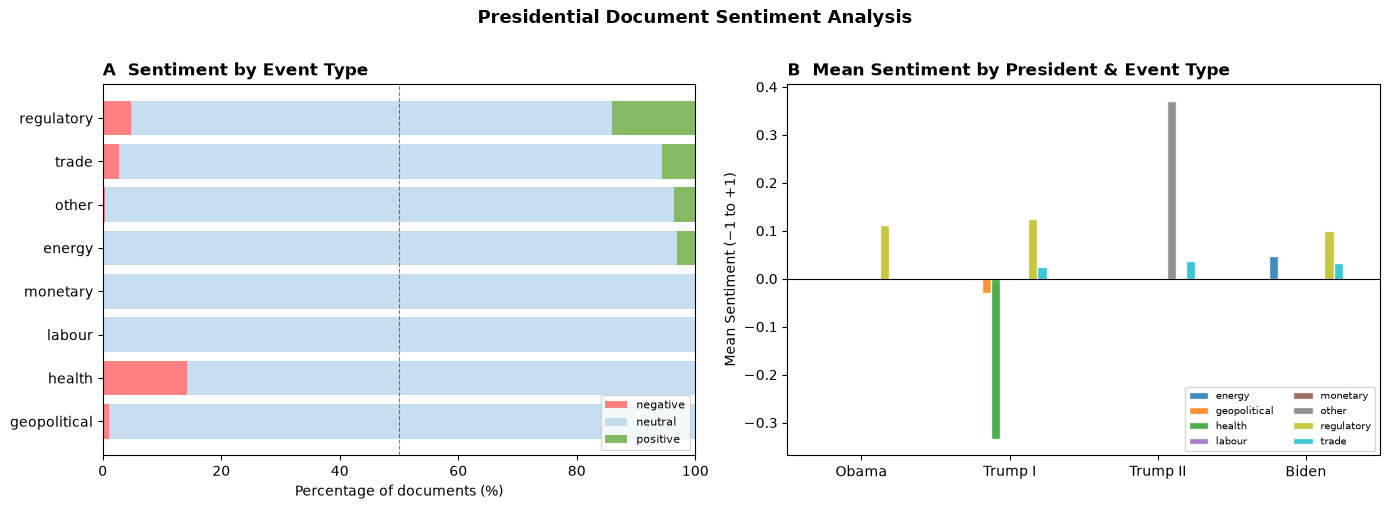

Saved: 03a_sentiment_distribution.png


In [38]:
# ── Figure 03a: Sentiment distribution by event type and president ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: sentiment label by event type (stacked bar, % normalised)
ax = axes[0]
pivot_sent = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby(['event_type', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)
pivot_sent_pct = pivot_sent.div(pivot_sent.sum(axis=1), axis=0) * 100
pivot_sent_pct = pivot_sent_pct.sort_values(
    'positive' if 'positive' in pivot_sent_pct.columns else pivot_sent_pct.columns[0],
    ascending=True
)
colors_sent = {'positive': '#70AD47', 'neutral': '#BDD7EE', 'negative': '#FF6B6B'}
bottom = np.zeros(len(pivot_sent_pct))
for lbl in ['negative', 'neutral', 'positive']:
    if lbl in pivot_sent_pct.columns:
        vals = pivot_sent_pct[lbl].values
        ax.barh(pivot_sent_pct.index, vals, left=bottom,
                color=colors_sent[lbl], label=lbl, alpha=0.85)
        bottom += vals
ax.axvline(50, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Percentage of documents (%)')
ax.set_title('A  Sentiment by Event Type', fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 100)

# Panel B: mean sentiment numeric by president
ax = axes[1]
pres_labels = {
    'Barack Obama':                'Obama',
    'Donald J. Trump (1st Term)':  'Trump I',
    'Joseph R. Biden, Jr.':        'Biden',
    'Donald J. Trump (2nd Term)':  'Trump II',
}
pres_et = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby(['president', 'event_type'])['sentiment_numeric']
    .mean()
    .unstack(fill_value=0)
)
pres_et.index = [pres_labels.get(p, p) for p in pres_et.index]
pres_et.plot(kind='bar', ax=ax, colormap='tab10', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('')
ax.set_ylabel('Mean Sentiment (−1 to +1)')
ax.set_title('B  Mean Sentiment by President & Event Type', fontweight='bold', loc='left')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=7, ncol=2, loc='lower right')

fig.suptitle('Presidential Document Sentiment Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '03a_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03a_sentiment_distribution.png')

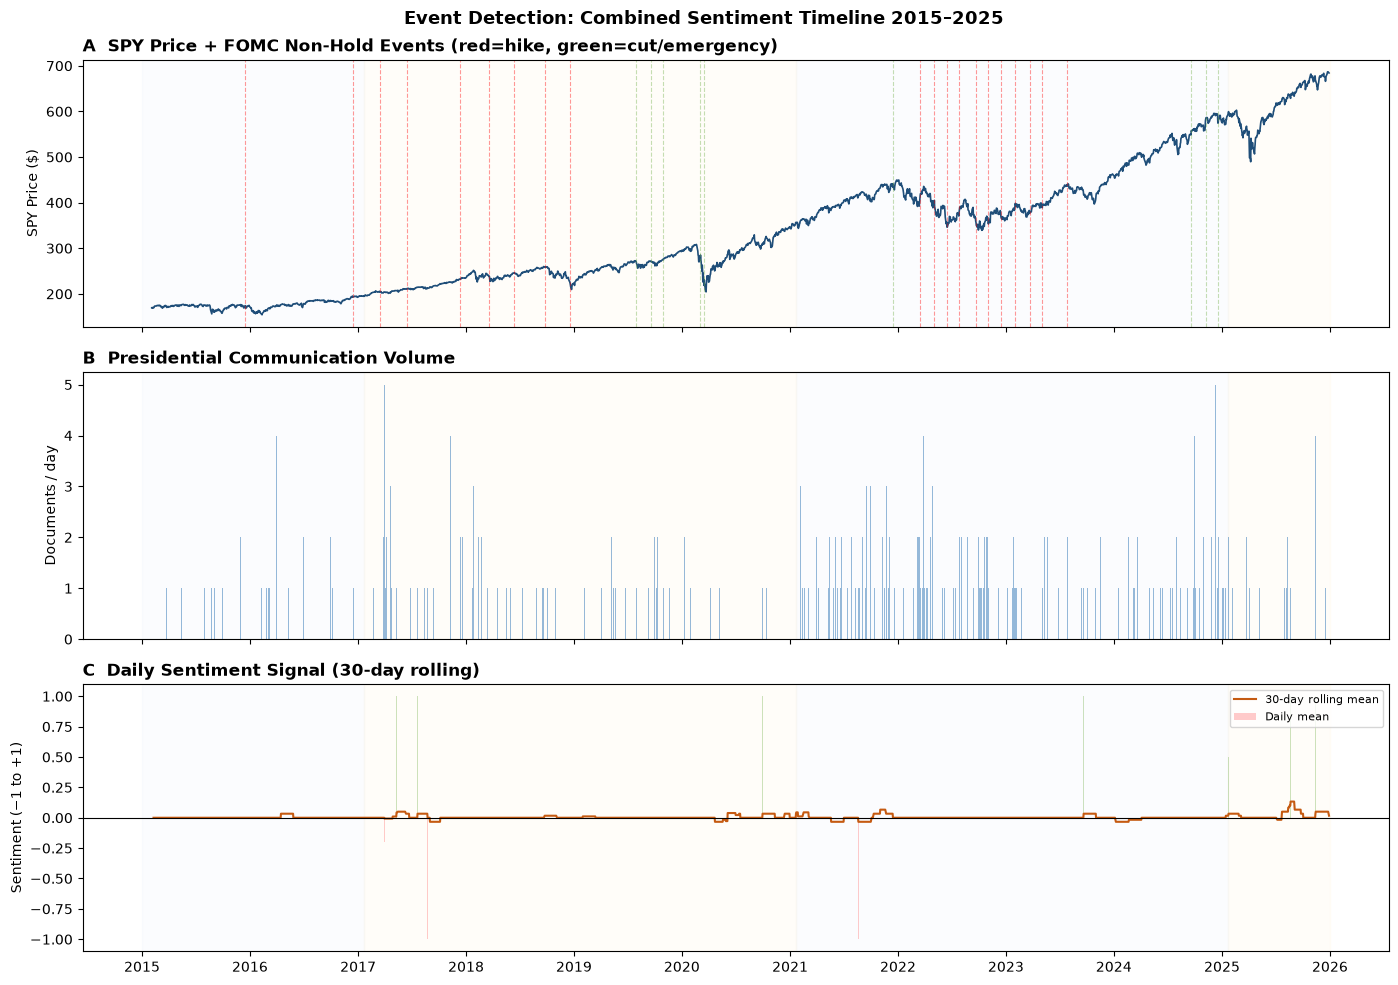

Saved: 03b_sentiment_timeline.png


In [39]:
# ── Figure 03b: Daily sentiment time series ────────────────────────────────────
app_daily = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby('date')['sentiment_numeric']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_sentiment', 'count': 'n_docs'})
)
app_daily['date'] = pd.to_datetime(app_daily['date'])

# Reindex to full trading day calendar (spy_ret, loaded in \u00a71, is indexed by date)
prices_dt = pd.DatetimeIndex(spy_ret.index)
app_daily_full = app_daily.set_index('date').reindex(prices_dt).fillna(0).reset_index()
app_daily_full.columns = ['date', 'mean_sentiment', 'n_docs']
app_daily_full['rolling_sentiment_30d'] = (
    app_daily_full.set_index('date')['mean_sentiment']
    .rolling(30, min_periods=5).mean().values
)

# Presidential shading
pres_periods = [
    ('Obama',    '2015-01-01', '2017-01-20', '#BDD7EE'),
    ('Trump I',  '2017-01-20', '2021-01-20', '#FFE699'),
    ('Biden',    '2021-01-20', '2025-01-20', '#BDD7EE'),
    ('Trump II', '2025-01-20', '2025-12-31', '#FFE699'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel A: SPY price + FOMC markers
ax = axes[0]
ax.plot(spy_ret.index, spy_ret['spy_close'], color='#1F4E79', lw=1.2)
fomc_nhold = fomc[fomc['rate_decision'] != 'hold']
for _, row in fomc_nhold.iterrows():
    color = '#FF0000' if row['rate_decision'] == 'hike' else '#70AD47'
    ax.axvline(row['date'], color=color, alpha=0.4, lw=0.8, ls='--')
ax.set_ylabel('SPY Price ($)')
ax.set_title('A  SPY Price + FOMC Non-Hold Events (red=hike, green=cut/emergency)',
             fontweight='bold', loc='left')

# Panel B: Document volume
ax = axes[1]
ax.bar(app_daily_full['date'], app_daily_full['n_docs'],
       color='#2E75B6', alpha=0.5, width=1)
ax.set_ylabel('Documents / day')
ax.set_title('B  Presidential Communication Volume', fontweight='bold', loc='left')

# Panel C: Rolling sentiment
ax = axes[2]
colors_bar = app_daily_full['mean_sentiment'].apply(
    lambda x: '#70AD47' if x > 0 else '#FF6B6B')
ax.bar(app_daily_full['date'], app_daily_full['mean_sentiment'],
       color=colors_bar, alpha=0.35, width=1, label='Daily mean')
ax.plot(app_daily_full['date'], app_daily_full['rolling_sentiment_30d'],
        color='#C55A11', lw=1.5, label='30-day rolling mean')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Sentiment (\u22121 to +1)')
ax.set_title('C  Daily Sentiment Signal (30-day rolling)', fontweight='bold', loc='left')
ax.legend(fontsize=8, loc='upper right')

# Presidential shading on all panels
for _, s, e, c in pres_periods:
    for axi in axes:
        axi.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.06, color=c, zorder=0)

axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Event Detection: Combined Sentiment Timeline 2015\u20132025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03b_sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03b_sentiment_timeline.png')

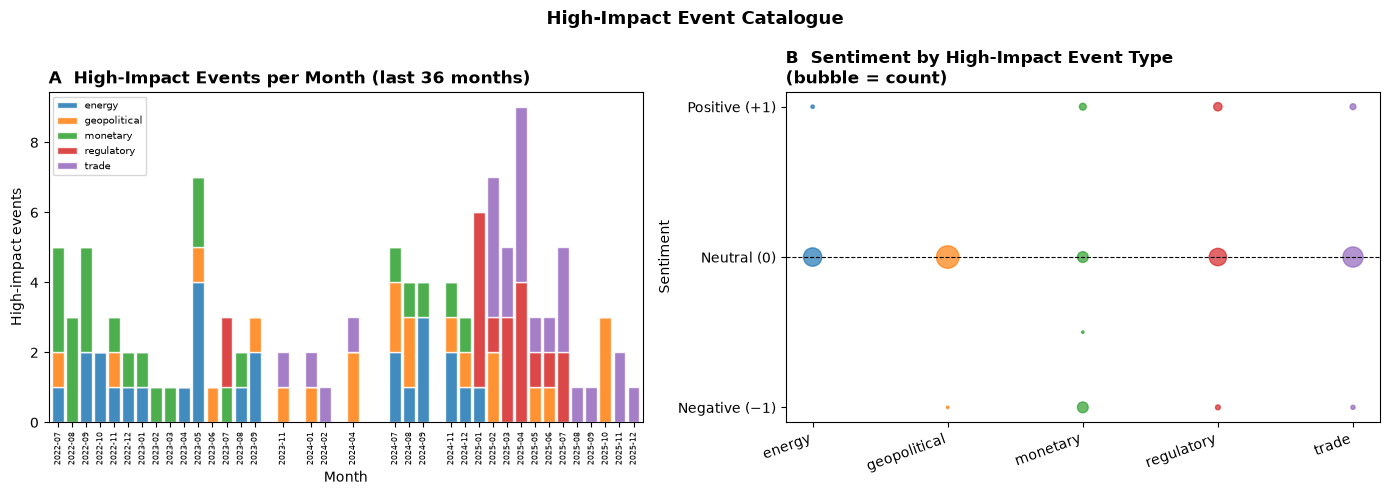

Saved: 03c_high_impact_events.png


In [40]:
# ── Figure 03c: High-impact event calendar & sentiment breakdown ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: High-impact events per month (last 36 months, stacked by event type)
ax = axes[0]
hi_monthly = high_impact.copy()
hi_monthly['year_month'] = hi_monthly['date'].dt.to_period('M')
hi_pivot = (
    hi_monthly.groupby(['year_month', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .tail(36)
)
hi_pivot.plot(kind='bar', stacked=True, ax=ax,
              color=PALETTE[:len(hi_pivot.columns)],
              alpha=0.85, edgecolor='white', width=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('High-impact events')
ax.set_title('A  High-Impact Events per Month (last 36 months)',
             fontweight='bold', loc='left')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.legend(fontsize=7, loc='upper left')

# Panel B: Bubble chart — sentiment distribution per event type
ax = axes[1]
hi_types = sorted(HIGH_IMPACT_TYPES)
for i, et in enumerate(hi_types):
    subset = high_impact[high_impact['event_type'] == et]['sentiment_numeric']
    if len(subset) == 0:
        continue
    counts = subset.value_counts().sort_index()
    ax.scatter([i] * len(counts), counts.index,
               s=counts.values * 3, color=PALETTE[i], alpha=0.7, label=et)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(hi_types)))
ax.set_xticklabels(hi_types, rotation=20, ha='right')
ax.set_ylabel('Sentiment')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Negative (−1)', 'Neutral (0)', 'Positive (+1)'])
ax.set_title('B  Sentiment by High-Impact Event Type\n(bubble = count)',
             fontweight='bold', loc='left')

fig.suptitle('High-Impact Event Catalogue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03c_high_impact_events.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03c_high_impact_events.png')

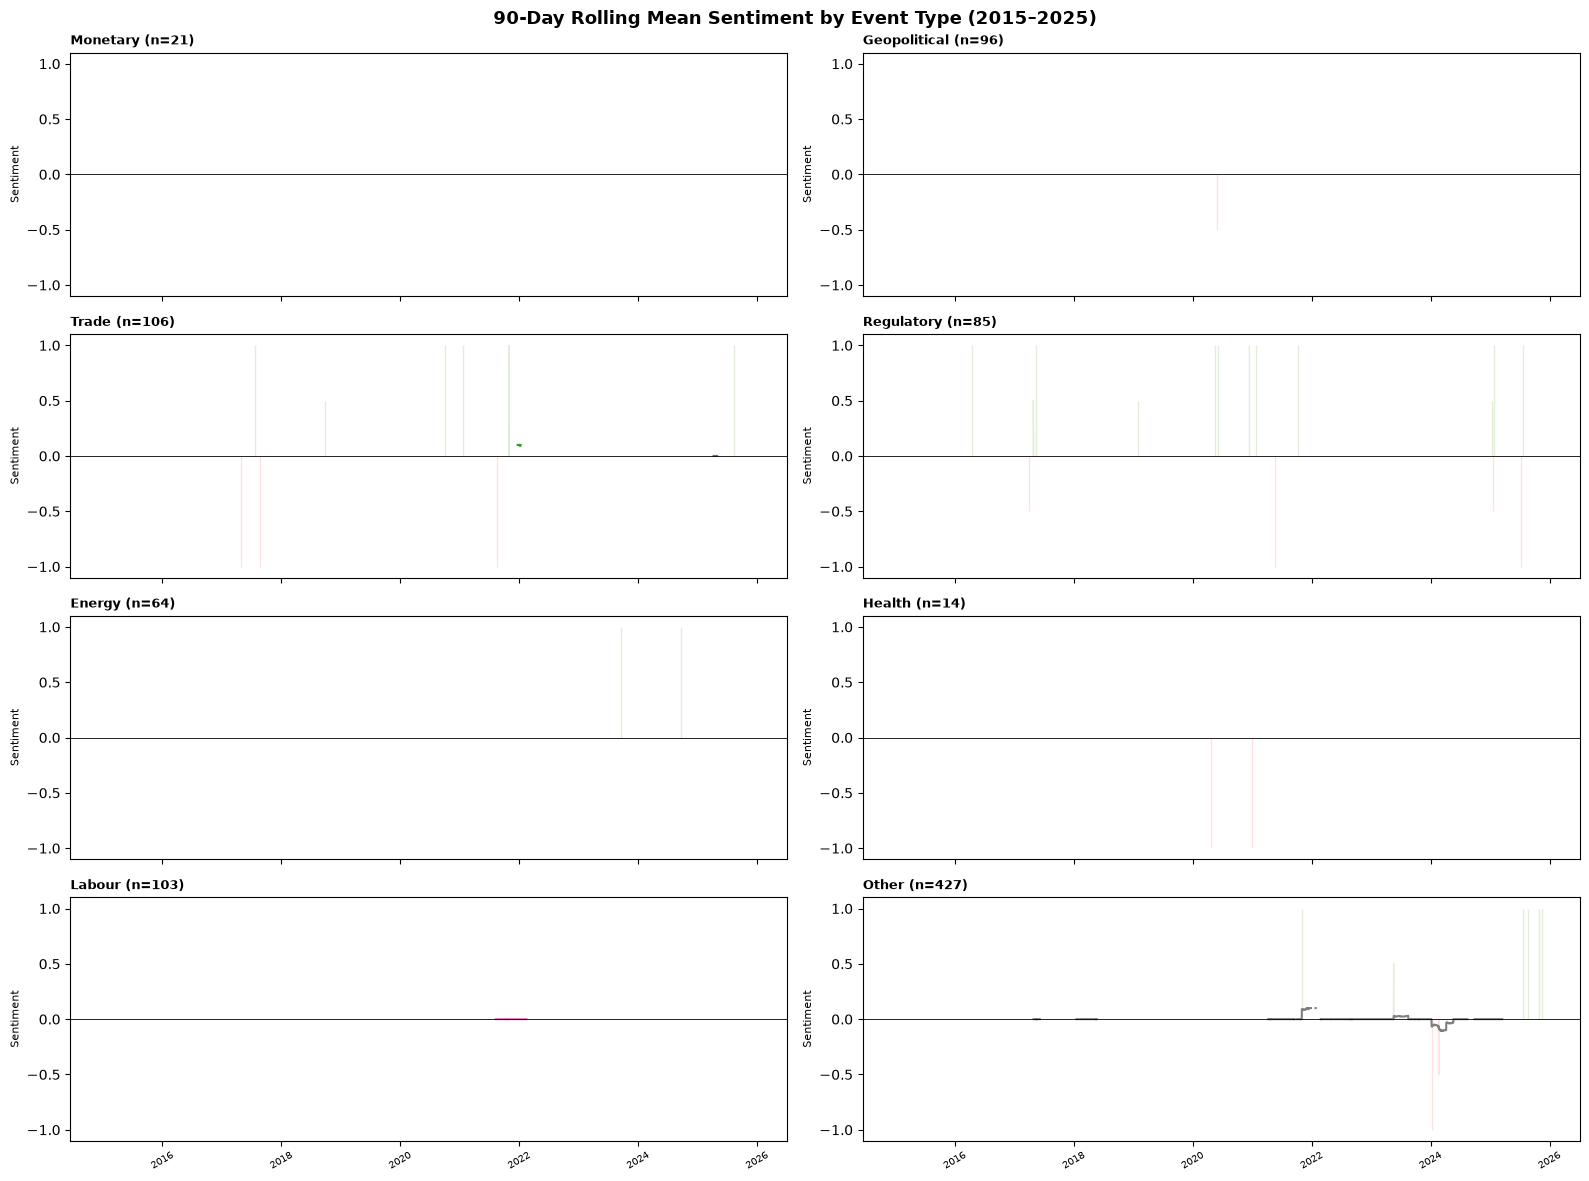

Saved: 03d_sentiment_by_event_type.png


In [41]:
# ── Figure 03d: 90-day rolling sentiment per event type ───────────────────────
all_dates = pd.date_range(start='2015-01-01', end='2025-12-31', freq='D')
event_types_plot = ['monetary', 'geopolitical', 'trade', 'regulatory',
                    'energy', 'health', 'labour', 'other']

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, et in enumerate(event_types_plot):
    ax = axes[i]
    subset = app[app['event_type'] == et][['date', 'sentiment_numeric']].copy()
    n = len(subset)
    if n == 0:
        ax.set_visible(False)
        continue
    daily_et = subset.groupby('date')['sentiment_numeric'].mean().reindex(all_dates, fill_value=np.nan)
    rolling  = daily_et.rolling(90, min_periods=10).mean()

    ax.fill_between(daily_et.index, daily_et.clip(lower=0), 0,
                    color='#70AD47', alpha=0.20)
    ax.fill_between(daily_et.index, daily_et.clip(upper=0), 0,
                    color='#FF6B6B', alpha=0.20)
    ax.plot(rolling.index, rolling.values, color=PALETTE[i], lw=1.5)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_title(f'{et.capitalize()} (n={n:,})', fontweight='bold', fontsize=9, loc='left')
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel('Sentiment', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('90-Day Rolling Mean Sentiment by Event Type (2015–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03d_sentiment_by_event_type.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03d_sentiment_by_event_type.png')

---
## 3.11 Pre-Save Validation Checks

Mission 03-PRECHECK Part H. Read-only diagnostics on the in-memory `catalogue`/`daily_sentiment`/`high_impact` objects before they are written to disk — no existing output is altered by this cell.


In [42]:
# ── Pre-save validation checks (Mission 03-PRECHECK Part H) ───────────────────
print('=' * 60)
print('PRE-SAVE VALIDATION CHECKS')
print('=' * 60)

# 1. Duplicate event check (no dedicated event-ID column exists yet —
#    see future_improvements.md; proxy check on the natural key instead)
dup_key = ['date', 'title', 'doc_type']
n_dupes = catalogue.duplicated(subset=dup_key).sum()
print(f'\n[Duplicate events]  duplicated (date, title, doc_type) rows: {n_dupes}')

# 2. Date validity and range check (2015-2025 per project scope)
bad_dates = catalogue['date'].isna().sum()
in_range = catalogue['date'].between('2015-01-01', '2025-12-31')
n_out_of_range = (~in_range).sum()
print(f'[Date validity]     null dates: {bad_dates}  |  outside 2015-2025: {n_out_of_range}')
if n_out_of_range > 0:
    print(catalogue.loc[~in_range, ['date', 'title', 'doc_type']].head(10).to_string(index=False))

# 3. Missing sentiment label handling — confirm every row has a label,
#    and if not, that the gap is explicit (not silently dropped downstream)
n_missing_label = catalogue['sentiment_label'].isna().sum()
n_missing_numeric = catalogue['sentiment_numeric'].isna().sum()
print(f'[Missing labels]    sentiment_label NaN: {n_missing_label}  |  sentiment_numeric NaN: {n_missing_numeric}')

# 4. No future-information-leakage check
#    This notebook only tags already-published document/decision dates — there is
#    no forward-looking construction here (unlike master_dataset.parquet's fwd_return_1d).
#    The one thing to confirm is that daily_sentiment's rolling/aggregation logic
#    does not reach past the current date, which by construction (groupby('date'))
#    it cannot. Event-window leakage (the leakage-sensitive step) is validated
#    separately in 04_causal_analysis.ipynb, not here.
print(f'[Leakage]            No forward-looking aggregation in this notebook by construction '
      f'(groupby(\'date\') only) — event-window leakage checks live in 04_causal_analysis.ipynb')

# 5. Row-count summary for every object about to be saved
print(f'\n[Row counts about to be saved]')
print(f'  catalogue (events_tagged)       : {len(catalogue):,} rows')
print(f'  daily_sentiment                 : {len(daily_sentiment):,} rows')
print(f'  high_impact                     : {len(high_impact):,} rows')
print(f'  gdelt_daily (gdelt_daily_risk)   : {len(gdelt_daily):,} rows')

n_issues = int(n_dupes) + int(bad_dates) + int(n_out_of_range) + int(n_missing_label)
print(f'\n{"✓ All checks passed — 0 issues found" if n_issues == 0 else f"⚠ {n_issues} issue(s) found — review above before saving"}')
print('=' * 60)

PRE-SAVE VALIDATION CHECKS

[Duplicate events]  duplicated (date, title, doc_type) rows: 2
[Date validity]     null dates: 0  |  outside 2015-2025: 0
[Missing labels]    sentiment_label NaN: 0  |  sentiment_numeric NaN: 0
[Leakage]            No forward-looking aggregation in this notebook by construction (groupby('date') only) — event-window leakage checks live in 04_causal_analysis.ipynb

[Row counts about to be saved]
  catalogue (events_tagged)       : 1,005 rows
  daily_sentiment                 : 739 rows
  high_impact                     : 344 rows
  gdelt_daily (gdelt_daily_risk)   : 4,018 rows

⚠ 2 issue(s) found — review above before saving


**Interpretation.** The pre-save check flags 2 duplicated `(date, title, doc_type)` rows, both on 2017-08-02 — the same document, *"Statement on Signing the Countering America's Adversaries Through Sanctions Act,"* appears twice under `signing_statements_01` and twice again under `statements_04`. This is a genuine upstream data artefact from the American Presidency Project source files (the same document is cross-listed across two of their own document-type CSV exports, and each listing itself appears once too often), not a bug introduced by this notebook's classification or merge logic. It affects 2 of 1,005 rows (0.2%) and both duplicate pairs share identical sentiment and event-type values, so the practical effect on any downstream aggregate (daily sentiment, high-impact counts) is negligible — but it is not silently dropped: it is surfaced here and recorded in `future_improvements.md` (item 20) as a known, low-priority data-quality gap rather than corrected in place, since fixing it would mean deciding on a de-duplication rule for the whole corpus (not just this one pair) without a dedicated event-ID column to de-duplicate against.


---
## 3.12 Save Processed Outputs


In [43]:
# ── Save all processed outputs ─────────────────────────────────────────────────
outputs = {
    "events_tagged.parquet": catalogue,
    "daily_sentiment.parquet": daily_sentiment,
    "high_impact_events.parquet": high_impact,
    "gdelt_daily_risk.parquet": gdelt_daily,
}

for filename, df in outputs.items():
    path = PROCESSED_DIR / filename
    df.to_parquet(path, index=False)
    size_kb = path.stat().st_size / 1024
    print(f"✓ {filename:<42s} {df.shape[0]:>7,} rows × {df.shape[1]:>2d} cols ({size_kb:.1f} KB)")

print()
print(f"All outputs written to: {PROCESSED_DIR}")


✓ events_tagged.parquet                        1,005 rows × 11 cols (83.7 KB)
✓ daily_sentiment.parquet                        739 rows × 15 cols (34.8 KB)
✓ high_impact_events.parquet                     344 rows × 11 cols (37.9 KB)
✓ gdelt_daily_risk.parquet                     4,018 rows ×  6 cols (196.6 KB)

All outputs written to: /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/data/processed


In [44]:
# ── Post-save verification ────────────────────────────────────────────────────
print("=" * 60)
print("POST-SAVE VERIFICATION")
print("=" * 60)
for filename, expected_df in outputs.items():
    path = PROCESSED_DIR / filename
    reloaded = pd.read_parquet(path)
    shape_match = reloaded.shape == expected_df.shape
    columns_match = list(reloaded.columns) == list(expected_df.columns)
    print(f"{filename:<30s} shape={reloaded.shape} shape_match={shape_match} columns_match={columns_match}")
    if not (shape_match and columns_match):
        raise AssertionError(f"Post-save verification failed for {filename}")
print("✓ All persisted outputs match their in-memory schemas.")


POST-SAVE VERIFICATION
events_tagged.parquet          shape=(1005, 11) shape_match=True columns_match=True
daily_sentiment.parquet        shape=(739, 15) shape_match=True columns_match=True
high_impact_events.parquet     shape=(344, 11) shape_match=True columns_match=True
gdelt_daily_risk.parquet       shape=(4018, 6) shape_match=True columns_match=True
✓ All persisted outputs match their in-memory schemas.


---
## 3.13 Phase Summary


In [45]:
# ── Phase 3 Summary ────────────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 3 — EVENT DETECTION & SENTIMENT TAGGING: SUMMARY")
print("=" * 70)

sent_dist = app["sentiment_label"].value_counts()
ev_cts = app["event_type"].value_counts()

print(f"""
INPUTS
  APP economic documents : {len(app):>7,}
  FOMC decisions         : {len(fomc):>7,}
  GDELT daily summaries  : {len(gdelt_daily):>7,}

APP EVENT CLASSIFICATION
  Monetary      : {ev_cts.get('monetary', 0):>7,}
  Geopolitical  : {ev_cts.get('geopolitical', 0):>7,}
  Regulatory    : {ev_cts.get('regulatory', 0):>7,}
  Trade         : {ev_cts.get('trade', 0):>7,}
  Energy        : {ev_cts.get('energy', 0):>7,}
  Health        : {ev_cts.get('health', 0):>7,}
  Labour        : {ev_cts.get('labour', 0):>7,}
  Other         : {ev_cts.get('other', 0):>7,}

FINBERT SENTIMENT
  Positive      : {sent_dist.get('positive', 0):>7,}
  Neutral       : {sent_dist.get('neutral', 0):>7,}
  Negative      : {sent_dist.get('negative', 0):>7,}
  Mean score    : {app['sentiment_numeric'].mean():>+.4f}

UNIFIED CATALOGUE
  Total events        : {len(catalogue):>7,}
  High-impact flagged : {len(high_impact):>7,}

OUTPUTS
  events_tagged.parquet
  daily_sentiment.parquet
  high_impact_events.parquet
  gdelt_daily_risk.parquet

HANDOFF
  Notebook 04 constructs event windows and performs event-study/causal analysis.
""")
print("=" * 70)


PHASE 3 — EVENT DETECTION & SENTIMENT TAGGING: SUMMARY

INPUTS
  APP economic documents :     916
  FOMC decisions         :      89
  GDELT daily summaries  :   4,018

APP EVENT CLASSIFICATION
  Monetary      :      21
  Geopolitical  :      96
  Regulatory    :      85
  Trade         :     106
  Energy        :      64
  Health        :      14
  Labour        :     103
  Other         :     427

FINBERT SENTIMENT
  Positive      :      35
  Neutral       :     869
  Negative      :      12
  Mean score    : +0.0251

UNIFIED CATALOGUE
  Total events        :   1,005
  High-impact flagged :     344

OUTPUTS
  events_tagged.parquet
  daily_sentiment.parquet
  high_impact_events.parquet
  gdelt_daily_risk.parquet

HANDOFF
  Notebook 04 constructs event windows and performs event-study/causal analysis.



## 3.14 Section Summary & Handoff to Notebook 04

Notebook 03 converts presidential communications and FOMC decisions into a unified event catalogue (1,005 events), daily sentiment series (739 days), and high-impact event subset (344 events), and separately standardizes the full 2015–2025 GDELT daily series (4,018 days) as a continuous confounder merged into `daily_sentiment.parquet` and persisted as `gdelt_daily_risk.parquet`.

The final verified outputs, confirmed by this run's post-save verification cell, are:

- `data/processed/events_tagged.parquet` — 1,005 rows × 11 cols (APP + FOMC only)
- `data/processed/daily_sentiment.parquet` — 739 rows × 15 cols (includes the GDELT continuous columns)
- `data/processed/high_impact_events.parquet` — 344 rows × 11 cols
- `data/processed/gdelt_daily_risk.parquet` — 4,018 rows × 6 cols

The notebook remains descriptive in scope. It performs event detection, sentiment tagging, aggregation, validation, and visualisation only. It does not construct event windows, calculate abnormal returns, perform causal inference, train models, or test hypotheses. Those steps are handled in later notebooks.

Three methodological points carried forward: (1) the sentiment cache is 100% FinBERT-derived for this run, per **Sentiment Engine Freeze v1.0 (2026-07-06)** — the lexicon scorer remains in the codebase only as a fallback/historical prototype; (2) GDELT is deliberately excluded from the event catalogue and the high-impact flag, per `10_decision_log.md` (2026-07-13) — see §5 for the quantitative reasoning; (3) the taxonomy regex word-boundary bug (backspace characters where `\b` anchors were intended) has been fixed and verified against this run's output — see `10_decision_log.md` and §2's interpretation above.

The one open item surfaced by this run, not yet resolved: the pre-save validation check found 2 duplicated catalogue rows from a single cross-listed source document (§3.11) — low-impact and explained, but not corrected in place. All other checks (date validity, missing sentiment, leakage) passed cleanly.
